# Reconstructing points for DeepMIP-Eocene-Phase2

This notebook is to reconstruct present-day points based on a particular rotation file and static polygons.
The static polygons are used to determine the plate ID(s) of the points we want to reconstruct.

This notebook has been specifically designed for DeepMIP-Eocene Phase2 (Lunt et al., 2026), but can be adapted to other plate tectonic models and/or times.

DeepMIP-Eocene Phase2 uses the paleogeography available as part of Lunt et al. (2026), which in turn uses the [Zahirovic et al. (2022)](https://doi.org/10.1002/gdj3.146) plate tectonic model in a **paleomagnetic reference frame (anchor plate ID = 701701)**. This plate tectonic model can be downloaded via [`plate_model_manager`](https://github.com/GPlates/plate-model-manager), and is also available with recent versions of GPlates (e.g., GPlates 2.4, 2.5).

The paleogeography and reconstructed sites for DeepMIP-Eocene-Phase 2 can be found on Zenodo: https://zenodo.org/records/17899195

---

Import things

In [1]:
import pygplates
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import geopandas
import pandas as pd
import plate_model_manager   # to download plate tectonic models. This can be installed via pip or conda
import gplately
import xarray as xr
import cmocean

# ---  set folders
main_dir = 'files'
plate_models = '%s/platemodels' % main_dir   # this is where we are downloading/reading the plate tectonic model from

# --- reconstruction time
reconstruction_time = 51   # target time for DeepMIP-Eocene Phase2

---

## Import plate tectonic model for DeepMIP-Eocene Phase2: Zahirovic et al. 2022

Path to relevant datafiles.
Need to have a rotation file and a static polygon file (or, other polygon file with plate IDs where your points lie).

In [2]:
# import target plate model: Zahirovic et al. (2022).
try:
    Z22_model_pmm = plate_model_manager.PlateModel(model_name="Zahirovic2022", data_dir=plate_models, readonly=True)
except:
    # if unable to connect to the servers, try to use the local files
    Z22_model_pmm = plate_model_manager.PlateModelManager().get_model("Zahirovic2022", data_dir=plate_models)

# get the plate model components
Z22_rotation_filename = Z22_model_pmm.get_rotation_model()
Z22_static_polygons_filename = Z22_model_pmm.get_static_polygons()
Z22_coastline_filename = Z22_model_pmm.get_coastlines()
Z22_topology_features = Z22_model_pmm.get_topologies()

# create a GPlately 'plate reconstruction' object
# NOTE: anchor_plate_id = 701701 ---> this is the PMAG reference frame
Z22_model = gplately.PlateReconstruction(Z22_rotation_filename, Z22_topology_features, Z22_static_polygons_filename, anchor_plate_id=701701)

## Specify points to reconstruct and determine their paleo-coordinates

In [3]:
path_to_some_data = 'https://zenodo.org/records/17899195/files/Hollis_2019_DeepMIP_compilation_PHASE2.xlsx?download=1'
# path_to_some_data = 'Hollis_2019_DeepMIP_compilation_PHASE2.xlsx'

In [4]:
df = pd.read_excel(path_to_some_data)
df

,site,timeslice,temperature,proxy,lat_present,long_present,plat_51Ma,plon_51Ma,mlat,mlon,...,mean plus reported error,deepmip lower error,deepmip upper error,min,max,v1,v2,v3,v4,v5
0,iodp 302,lp,lat,mbtcbt,87.87,136.18,76.919354,26.565270,82.81,66.91,...,15.72,15.00,15.72,14.67,15.88,1,1,1,0.0,1.0
1,iodp 302,petm,sst,tex86,87.87,136.18,76.919354,26.565270,82.81,66.91,...,-999.90,17.26,31.69,15.28,33.38,1,1,0,1.0,1.0
2,iodp 302,petm,lat,mbtcbt,87.50,136.10,77.116885,27.958116,82.74,69.64,...,20.70,19.16,20.70,18.03,20.98,1,1,1,0.0,1.0
3,Ellesmere Island,eeco,lat,del18o,78.80,-82.00,70.765365,-16.389659,78.89,-35.26,...,9.50,-1.50,9.50,-999.90,-999.90,1,1,1,1.0,0.0
4,Faddeevsky Island,petm,lat,ca,76.00,141.80,79.483713,89.829616,75.82,124.00,...,22.10,16.00,22.10,-999.90,-999.90,1,1,1,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,odp 689,lp,sst,del18O,-64.31,3.06,-70.798966,0.463643,-60.59,-4.35,...,-999.90,10.79,15.71,10.76,15.92,0,1,0,0.0,0.0
205,odp 689,petm,sst,del18O,-64.31,3.06,-70.798966,0.463643,-60.59,-4.35,...,-999.90,15.73,16.23,15.70,16.26,0,1,0,0.0,0.0
206,odp 690,eeco,sst,del18O,-65.33,1.28,-71.754071,-2.146498,-62.30,-5.76,...,-999.90,6.96,17.03,5.28,18.45,0,1,0,0.0,0.0
207,odp 690,lp,sst,del18O,-65.33,1.28,-71.754071,-2.146498,-61.35,-6.04,...,-999.90,8.82,15.50,7.44,16.01,0,1,0,0.0,0.0


This csv has a `long_present` and `lat_present` column, which we can use to reconstruct by creating a [`GPlately.Points`](https://gplates.github.io/gplately/latest/sphinx/html/generated/gplately.Points.html) object.

In [5]:
# Create a gplately Points object. This is the easiest way to reconstruct the points, though we can reconstruct in pure pygplates if we want to avoid gplately
# This will reconstruct the points using PlateReconstruction model (the Muller08model) that we created earlier.
# Specifically, it uses the rotation model (to figure out where the points reconstruct to) and the static polygons (to assign plate IDs to the points)

# here, we are initialising with time=0 (default). 

# NOTE here we are creating the gplately.Points object with the Z22 model
gpts = gplately.Points(Z22_model, df['long_present'], df['lat_present'])

Reconstruct the points through time

In [6]:
print('Reconstruction time is: %s Ma' % reconstruction_time)

# reconstruct out points. return_array=True gives us the reconstructed coordinates (lon and lat) as arrays
rlons, rlats = gpts.reconstruct(reconstruction_time, return_array=True)

Reconstruction time is: 51 Ma


Add the reconstructed lon and lat to our original dataframe

In [7]:
df['longitude_51Ma_Z22'] = rlons
df['latitude_51Ma_Z22'] = rlats

In [8]:
df

,site,timeslice,temperature,proxy,lat_present,long_present,plat_51Ma,plon_51Ma,mlat,mlon,...,deepmip upper error,min,max,v1,v2,v3,v4,v5,longitude_51Ma_Z22,latitude_51Ma_Z22
0,iodp 302,lp,lat,mbtcbt,87.87,136.18,76.919354,26.565270,82.81,66.91,...,15.72,14.67,15.88,1,1,1,0.0,1.0,26.565270,76.919354
1,iodp 302,petm,sst,tex86,87.87,136.18,76.919354,26.565270,82.81,66.91,...,31.69,15.28,33.38,1,1,0,1.0,1.0,26.565270,76.919354
2,iodp 302,petm,lat,mbtcbt,87.50,136.10,77.116885,27.958116,82.74,69.64,...,20.70,18.03,20.98,1,1,1,0.0,1.0,27.958116,77.116885
3,Ellesmere Island,eeco,lat,del18o,78.80,-82.00,70.765365,-16.389659,78.89,-35.26,...,9.50,-999.90,-999.90,1,1,1,1.0,0.0,-16.389659,70.765365
4,Faddeevsky Island,petm,lat,ca,76.00,141.80,79.483713,89.829616,75.82,124.00,...,22.10,-999.90,-999.90,1,1,1,1.0,1.0,89.829616,79.483713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,odp 689,lp,sst,del18O,-64.31,3.06,-70.798966,0.463643,-60.59,-4.35,...,15.71,10.76,15.92,0,1,0,0.0,0.0,0.463643,-70.798966
205,odp 689,petm,sst,del18O,-64.31,3.06,-70.798966,0.463643,-60.59,-4.35,...,16.23,15.70,16.26,0,1,0,0.0,0.0,0.463643,-70.798966
206,odp 690,eeco,sst,del18O,-65.33,1.28,-71.754071,-2.146498,-62.30,-5.76,...,17.03,5.28,18.45,0,1,0,0.0,0.0,-2.146498,-71.754071
207,odp 690,lp,sst,del18O,-65.33,1.28,-71.754071,-2.146498,-61.35,-6.04,...,15.50,7.44,16.01,0,1,0,0.0,0.0,-2.146498,-71.754071


## Plot

See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler


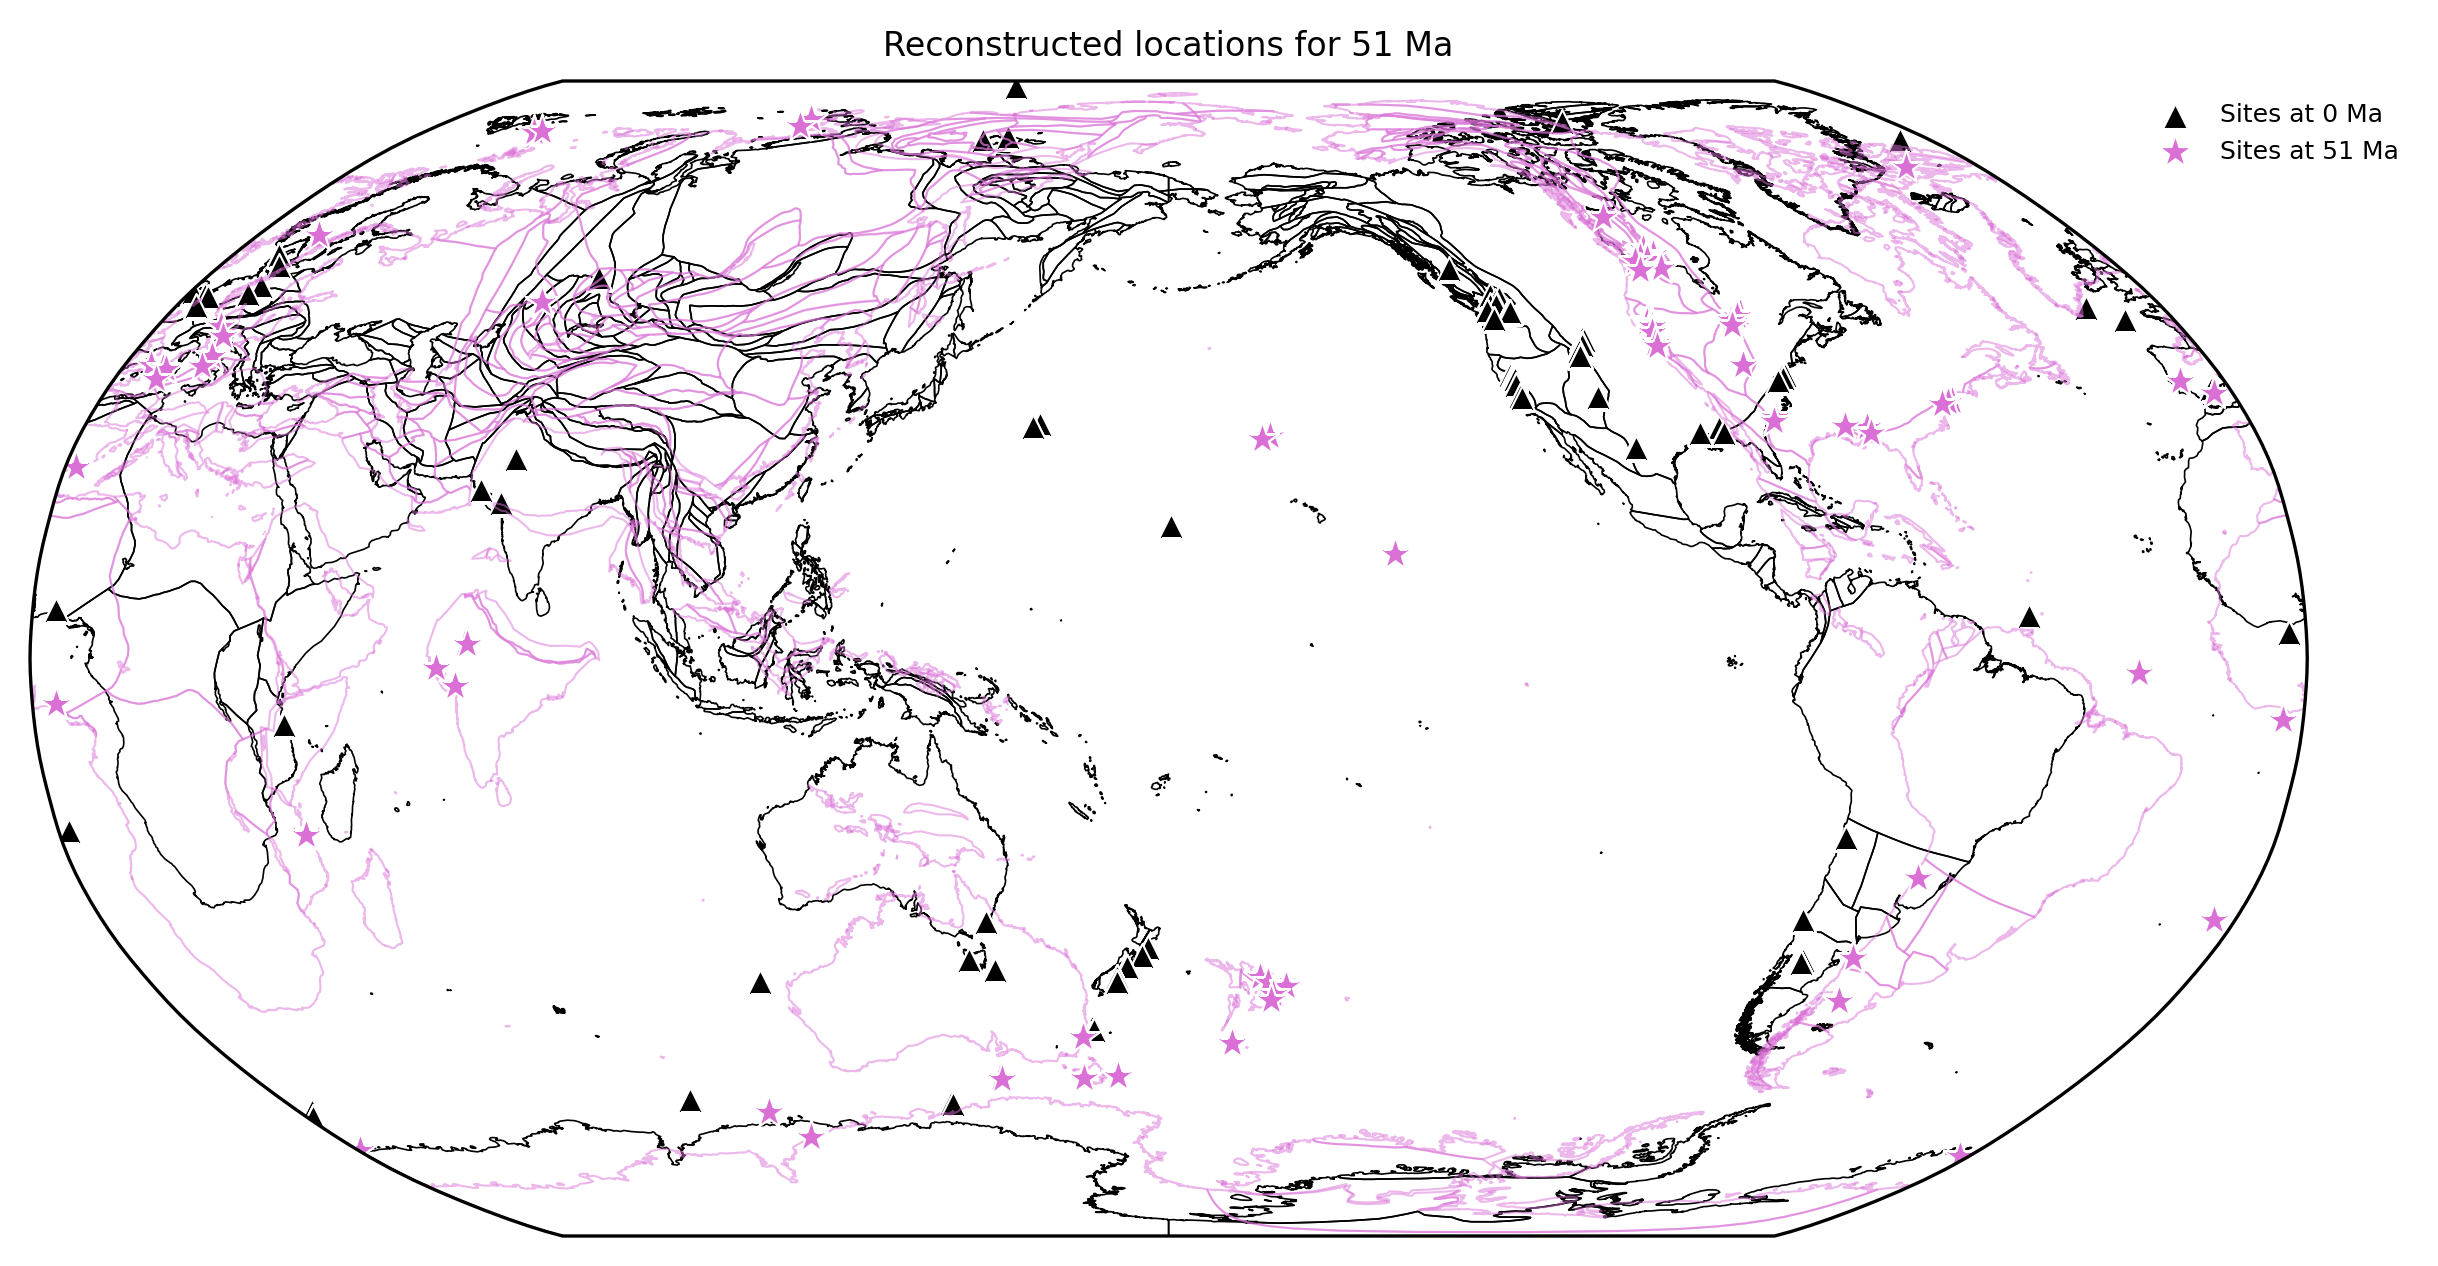

In [9]:
# Plot the original vs reconstructed sites

# need to create a 'PlotTopologies' object - this is a counterintuitive name (I know) but is how 
# we can easily plot the plate tectonic model and its components at different times if we wanted to do so
# Whatever we pass to 'coastlines' can be plotted using 'plot_coastlines' later etc.
gplot = gplately.PlotTopologies(Z22_model, coastlines=Z22_coastline_filename, continents=None, COBs=None)

# --- Set up a GeoAxis plot (cartopy version)
fig = plt.figure(figsize=(12, 5), dpi=300)
ax = fig.add_subplot(111, projection=ccrs.Robinson(central_longitude=180))
ax.set_global()
ax.set_title("Reconstructed locations for 51 Ma", fontsize=8)

# --- Plot 0 Ma
gplot.time = 0  # in Ma. This part of the plot will be whatever is set here
gplot.plot_coastlines(ax, color='black', linewidth=0.4, label='Coastlines at 0 Ma')

# plot sites - based on the present-day lon/lat of our geodataframe
sc = ax.scatter(df['long_present'], df['lat_present'], color='black',
                transform=ccrs.PlateCarree(), label='Sites at 0 Ma', marker='^', edgecolors='white', linewidths=0.5)

# --- Plot 15 Ma
gplot.time = reconstruction_time  # set to a different time for plotting
gplot.plot_coastlines(ax, color='orchid', linewidth=0.5, label='Coastlines at 51 Ma', alpha=0.5) 
# plot sites, based on the reconstructed position
sc = ax.scatter(df['longitude_51Ma_Z22'], df['latitude_51Ma_Z22'], color='orchid', marker='*', s=70,
                transform=ccrs.PlateCarree(), label='Sites at %s Ma' % reconstruction_time, edgecolors='white', linewidths=0.5)

ax.legend(frameon=False, fontsize=6, bbox_to_anchor = (1.05,1))
plt.show()

## Plot with DeepMIP-Eocene-Phase2 paleogeography

In [10]:
deepmip_paleogeography_filename = 'OutputFiles/deepmip2-eocene-paleogeography.nc'
ds_paleogeo = xr.open_dataset(deepmip_paleogeography_filename)
ds_paleogeo

<xarray.Dataset> Size: 4MB
Dimensions:  (lat: 721, lon: 1441)
Coordinates:
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8 180.0
Data variables:
    topo     (lat, lon) float32 4MB ...
Attributes:
    Conventions:  CF-1.7
    title:        Paleogeography boundary condition for DeepMIP-Eocene-p2
    history:      
    description:  Reconstruction is at 51 Ma using the Zahirovic et al. (2022...
    GMT_version:  6.6.0 [MP]

See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler


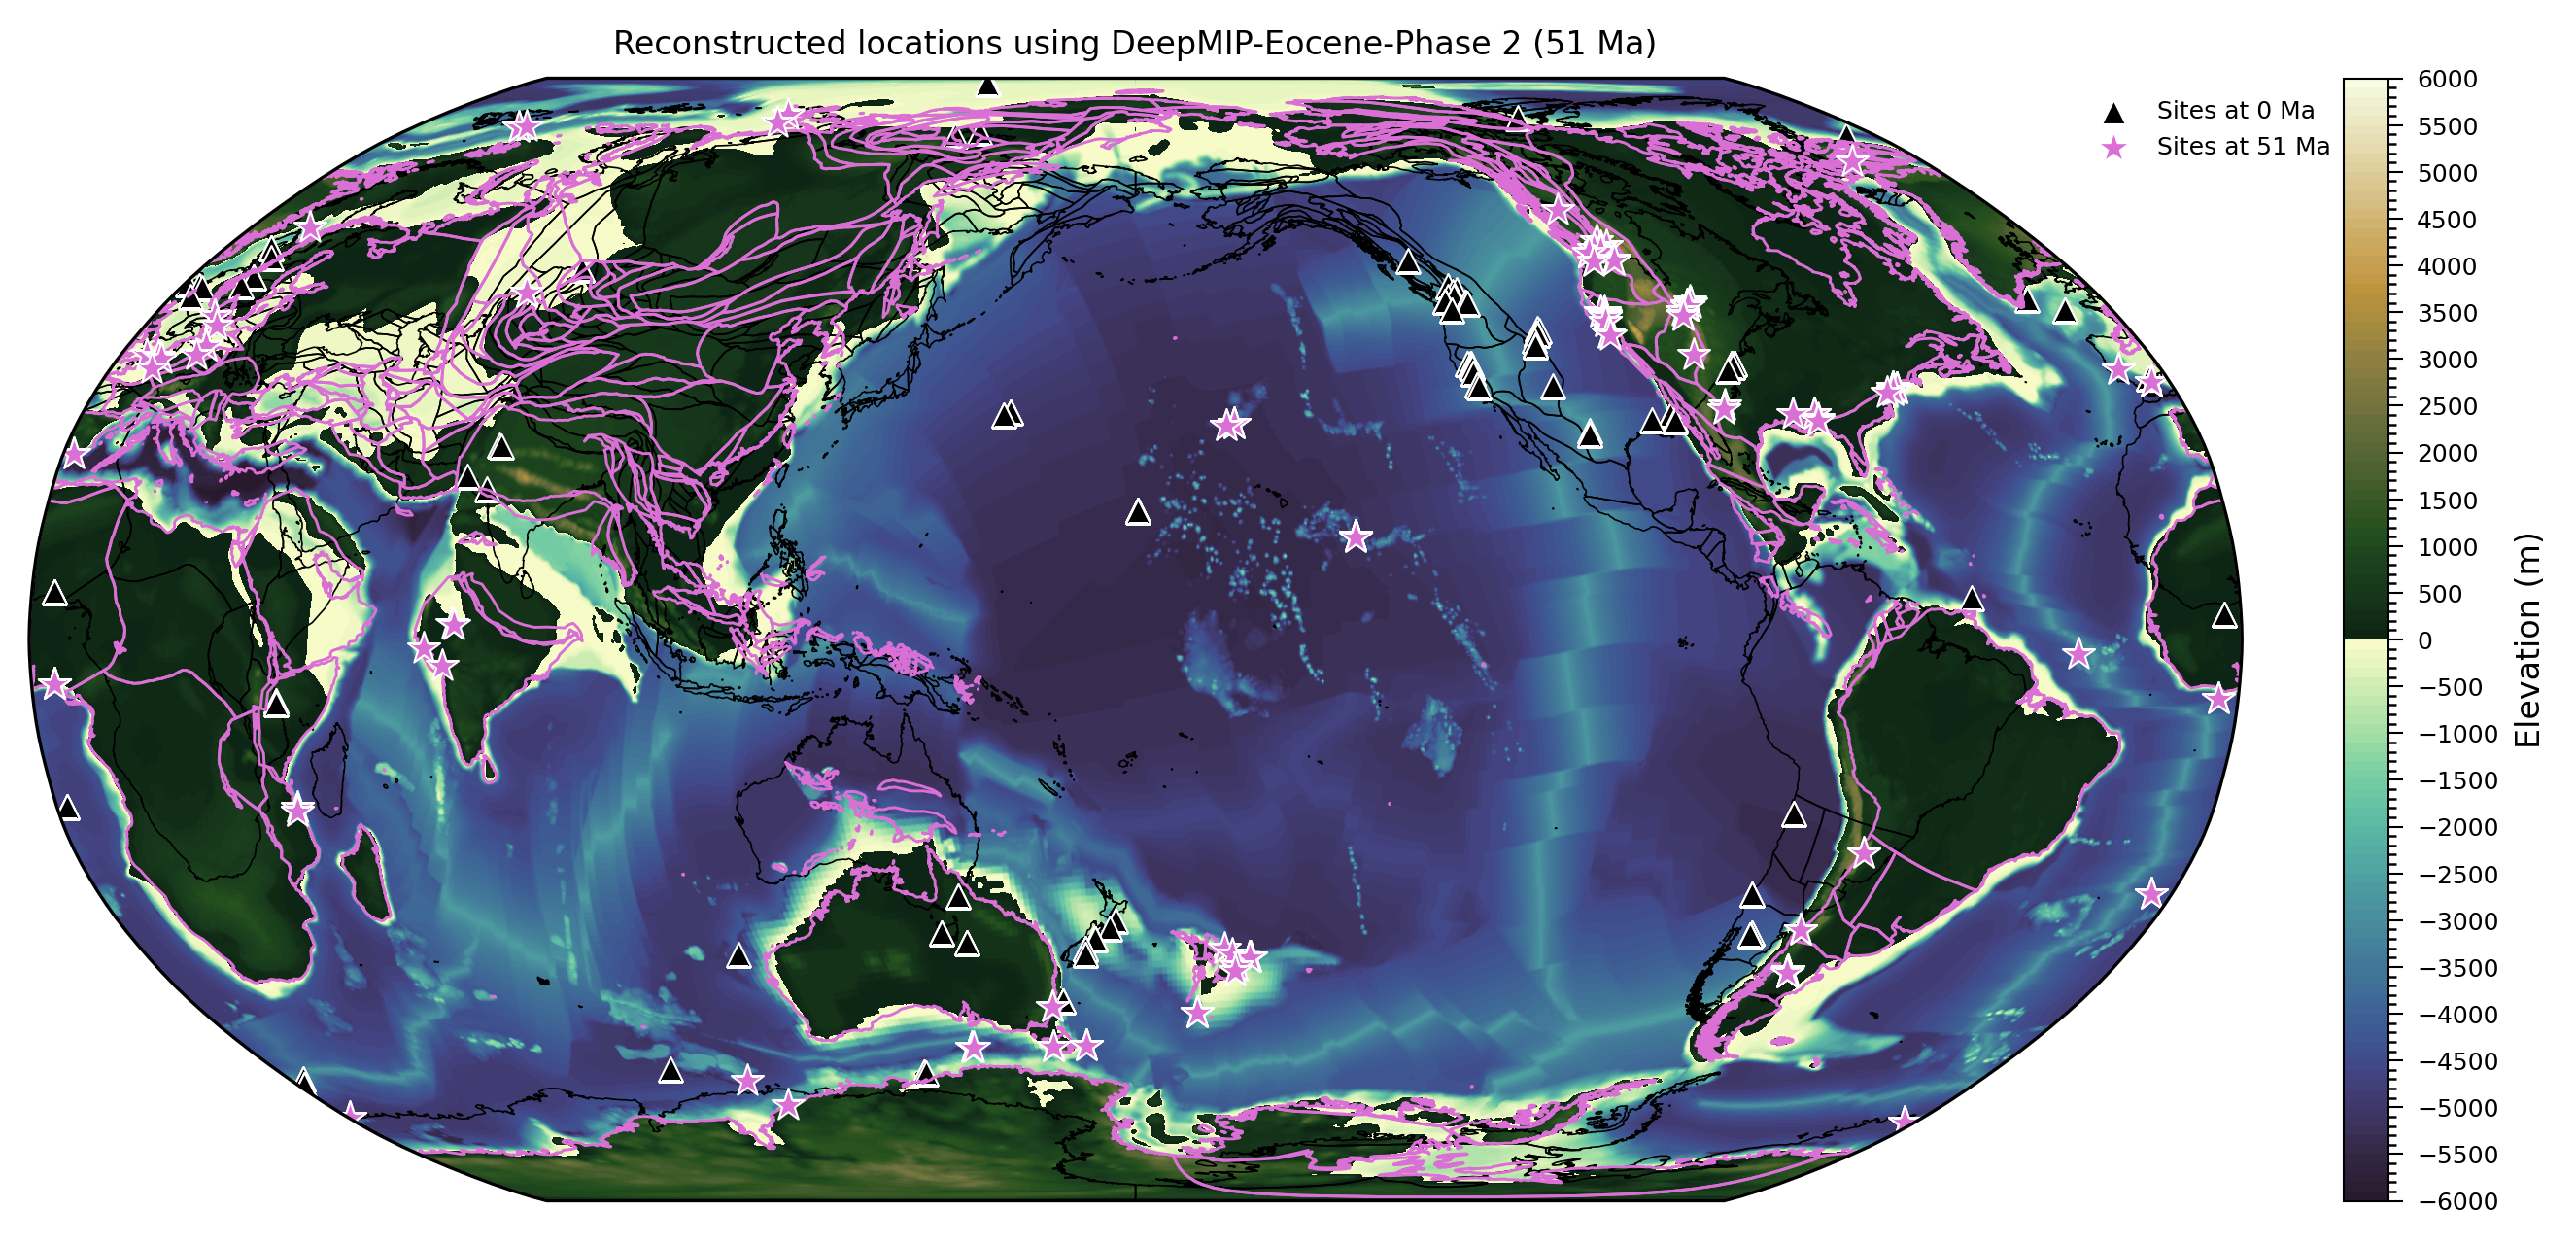

In [11]:
# Plot the original vs reconstructed sites

# need to create a 'PlotTopologies' object - this is a counterintuitive name (I know) but is how 
# we can easily plot the plate tectonic model and its components at different times if we wanted to do so
# Whatever we pass to 'coastlines' can be plotted using 'plot_coastlines' later etc.
gplot = gplately.PlotTopologies(Z22_model, coastlines=Z22_coastline_filename, continents=None, COBs=None)

# --- Set up a GeoAxis plot (cartopy version)
fig = plt.figure(figsize=(12, 5), dpi=300)
ax = fig.add_subplot(111, projection=ccrs.Robinson(central_longitude=180))
ax.set_global()
ax.set_title("Reconstructed locations using DeepMIP-Eocene-Phase 2 (51 Ma)", fontsize=8)

# --- plot the MioMIP2-Phase 2 netcdf
contour_levels = np.arange(-6000, 6100, 100)
cmap = cmocean.cm.topo
norm = BoundaryNorm(contour_levels, ncolors=cmap.N, clip=True)
p = ax.contourf(ds_paleogeo.lon.values,
                ds_paleogeo.lat.values,
                ds_paleogeo.topo.values, levels=contour_levels,
                transform=ccrs.PlateCarree(), cmap=cmap, norm=norm,
                vmin=contour_levels[0], vmax=contour_levels[-1])

# plot colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.35, axes_class=plt.Axes)
cbar = plt.colorbar(p, cax=cax, ticks=np.arange(-6000, 6500, 500))
cbar.ax.tick_params(labelsize=6, width=0.5, length=3.5)
cbar.set_label('Elevation (m)', size=8)
cbar.outline.set_linewidth(0.5)

# --- Plot 0 Ma
gplot.time = 0  # in Ma. This part of the plot will be whatever is set here
gplot.plot_coastlines(ax, color='black', linewidth=0.4, label='Coastlines at 0 Ma')

# plot sites - based on the present-day lon/lat of our geodataframe
sc = ax.scatter(df['long_present'], df['lat_present'], color='black',
                transform=ccrs.PlateCarree(), label='Sites at 0 Ma', marker='^', edgecolors='white', linewidths=0.5)

# --- Plot 51 Ma
gplot.time = reconstruction_time  # set to a different time for plotting
gplot.plot_coastlines(ax, color='orchid', linewidth=0.7, label='Coastlines at 51 Ma')
# plot sites, based on the reconstructed position
sc = ax.scatter(df['longitude_51Ma_Z22'], df['latitude_51Ma_Z22'], color='orchid', marker='*', s=70,
                transform=ccrs.PlateCarree(), label='Sites at %s Ma' % reconstruction_time, edgecolors='white', linewidths=0.5)

ax.legend(frameon=False, fontsize=6, bbox_to_anchor = (1.05,1))
plt.show()